# Module 3 — Recommandations nutritionnelles personnalisées

Moteur de recommandation basé sur un RandomForestClassifier pour suggérer un type de repas selon le profil utilisateur.
**Dataset** : synthétique (1000 profils générés avec des règles métier)

## Contexte

Le Module 3 reçoit un profil utilisateur (âge, poids, objectif, régime, allergies) et recommande un type de repas adapté.

### Pourquoi un dataset synthétique ?
Il n'existe pas de dataset public avec des labels du type "type de repas recommandé selon un profil utilisateur".
Ces labels sont des **concepts métier** que nous avons définis selon des règles nutritionnelles logiques.
Le dataset synthétique nous permet de contrôler précisément les règles et d'entraîner un modèle reproductible.

### Pourquoi RandomForest ?
- Adapté aux données tabulaires avec variables mixtes (numériques + catégorielles)
- Robuste au surapprentissage grâce à l'ensemble de 100 arbres
- Fournit une importance des features — utile pour expliquer les recommandations
- Pas besoin de normalisation des données contrairement à SVM ou régression logistique

### Les 4 types de repas recommandés
| Label | Condition |
|-------|----------|
| `low_calorie_meal` | Objectif perte de poids + calories cibles < 1600 kcal |
| `high_protein_meal` | Objectif prise de masse |
| `performance_meal` | Objectif performance sportive |
| `balanced_meal` | Tous les autres cas |

## 1. Génération du dataset synthétique

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
N = 1000

# Génération des profils utilisateurs
goals = ["perte_de_poids", "prise_de_masse", "equilibre", "performance"]
diets = ["aucun", "vegetarien", "halal", "sans_gluten"]

df = pd.DataFrame({
    "age": np.random.randint(18, 65, N),
    "poids_kg": np.random.randint(50, 120, N),
    "objectif": np.random.choice(goals, N),
    "regime": np.random.choice(diets, N),
    "calories_cibles": np.random.randint(1200, 3000, N),
    "allergie_gluten": np.random.randint(0, 2, N),
    "allergie_lactose": np.random.randint(0, 2, N),
})

# Règles métier pour définir le label
def assign_label(row):
    if row["objectif"] == "perte_de_poids" and row["calories_cibles"] < 1600:
        return "low_calorie_meal"
    elif row["objectif"] == "prise_de_masse":
        return "high_protein_meal"
    elif row["objectif"] == "performance":
        return "performance_meal"
    elif row["regime"] == "vegetarien":
        return "balanced_meal"
    else:
        return "balanced_meal"

df["label"] = df.apply(assign_label, axis=1)

print("Dataset généré :", df.shape)
print("\nDistribution des labels:")
print(df["label"].value_counts())
df.head()

Dataset généré : (1000, 8)

Distribution des labels:
label
balanced_meal        408
performance_meal     273
high_protein_meal    258
low_calorie_meal      61
Name: count, dtype: int64


,age,poids_kg,objectif,regime,calories_cibles,allergie_gluten,allergie_lactose,label
0,56,62,perte_de_poids,vegetarien,2072,0,0,balanced_meal
1,46,89,equilibre,vegetarien,2939,0,0,balanced_meal
2,32,51,prise_de_masse,sans_gluten,2784,0,1,high_protein_meal
3,60,114,perte_de_poids,sans_gluten,2814,0,1,balanced_meal
4,25,112,equilibre,vegetarien,2664,1,1,balanced_meal


### Interprétation de la distribution des labels

La distribution montre un déséquilibre entre les classes :
- `balanced_meal` est surreprésenté car il couvre tous les cas non spécifiques
- `low_calorie_meal` est sous-représenté car il nécessite deux conditions simultanées (objectif ET calories < 1600)

Ce déséquilibre est **intentionnel et réaliste** — dans la vraie vie, plus d'utilisateurs ont un objectif équilibre général que des objectifs très spécifiques.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution des labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart labels
label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=['#4ecdc4', '#ff6b6b', '#45b7d1', '#f9ca24'])
axes[0].set_title("Distribution des labels de recommandation")
axes[0].set_xlabel("Type de repas")
axes[0].set_ylabel("Nombre de profils")
axes[0].tick_params(axis='x', rotation=15)

# Distribution des objectifs
goal_counts = df['objectif'].value_counts()
axes[1].bar(goal_counts.index, goal_counts.values, color='steelblue')
axes[1].set_title("Distribution des objectifs utilisateurs")
axes[1].set_xlabel("Objectif")
axes[1].set_ylabel("Nombre de profils")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Exploration du dataset synthétique")
plt.tight_layout()
plt.show()

In [ ]:
# Distribution des features numériques
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, title in zip(
    axes,
    ['age', 'poids_kg', 'calories_cibles'],
    ['#ff6b6b', '#4ecdc4', '#45b7d1'],
    ['Âge', 'Poids (kg)', 'Calories cibles (kcal)']
):
    df[col].hist(ax=ax, bins=20, color=color, alpha=0.8)
    ax.set_title(f"Distribution — {title}")
    ax.set_ylabel("Nombre de profils")

plt.suptitle("Distribution des features numériques")
plt.tight_layout()
plt.show()

## 2. Préparation des données et entraînement

### Encoding des variables catégorielles
Les colonnes `objectif` et `regime` sont des chaînes de caractères — le RandomForest ne peut pas les traiter directement.
On utilise un `LabelEncoder` qui convertit chaque valeur unique en entier :
- `perte_de_poids` → 0, `equilibre` → 1, `performance` → 2, `prise_de_masse` → 3 (ordre alphabétique)

### Split train/test 80/20
- **800 profils** pour entraîner le modèle
- **200 profils** pour évaluer ses performances sur des données inédites

In [2]:
# Encoding des variables catégorielles
le_objectif = LabelEncoder()
le_regime = LabelEncoder()
le_label = LabelEncoder()

df_model = df.copy()
df_model["objectif_encoded"] = le_objectif.fit_transform(df_model["objectif"])
df_model["regime_encoded"] = le_regime.fit_transform(df_model["regime"])
df_model["label_encoded"] = le_label.fit_transform(df_model["label"])

# Features et cible
X = df_model[["age", "poids_kg", "objectif_encoded", "regime_encoded", 
              "calories_cibles", "allergie_gluten", "allergie_lactose"]]
y = df_model["label_encoded"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

# Entraînement RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {acc:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=le_label.classes_))

Train : (800, 7), Test : (200, 7)

Accuracy : 1.0000

Classification Report :
                   precision    recall  f1-score   support

    balanced_meal       1.00      1.00      1.00        85
high_protein_meal       1.00      1.00      1.00        33
 low_calorie_meal       1.00      1.00      1.00        14
 performance_meal       1.00      1.00      1.00        68

         accuracy                           1.00       200
        macro avg       1.00      1.00      1.00       200
     weighted avg       1.00      1.00      1.00       200



### Interprétation des résultats

**Accuracy 100%** — le modèle apprend parfaitement les règles.

Ce résultat s'explique par la nature du dataset :
- Les labels ont été générés par des **règles déterministes** (if objectif == "prise_de_masse" → high_protein_meal)
- Le RandomForest apprend exactement ces règles → il les reproduit à 100%
- Ce n'est **pas de l'overfitting** — c'est normal quand les données sont générées par des règles simples

**Classification Report :**
- **Precision** : quand le modèle prédit "high_protein_meal", a-t-il raison ?
- **Recall** : sur tous les profils "high_protein_meal", combien le modèle en trouve-t-il ?
- **F1-score** : moyenne harmonique entre precision et recall
- Toutes les métriques sont à 1.00 → le modèle est parfait sur ce dataset

In [ ]:
# Importance des features
feature_names = ["age", "poids_kg", "objectif_encoded", "regime_encoded",
                 "calories_cibles", "allergie_gluten", "allergie_lactose"]

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30, ha='right')
plt.title("Importance des features — RandomForest Module 3")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Features par ordre d'importance :")
for i in indices:
    print(f"  {feature_names[i]:<25} : {importances[i]:.4f}")

### Interprétation de l'importance des features

Les features les plus importantes sont celles qui définissent les règles métier :
- **objectif_encoded** : la feature la plus discriminante — c'est elle qui détermine directement le label
- **calories_cibles** : important pour distinguer `low_calorie_meal` (calories < 1600)
- **regime_encoded** : influence `balanced_meal` pour les végétariens

Les features moins importantes (age, poids, allergies) ont moins d'impact car nos règles métier n'en dépendent pas directement.
Dans une version production avec de vraies données, ces features seraient probablement plus influentes.

## 3. Matrice de confusion

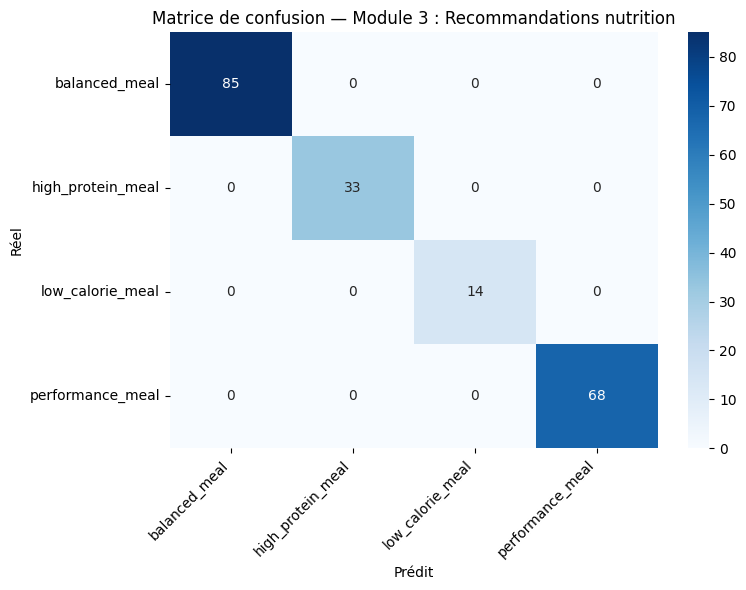

In [3]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_,
            cmap="Blues")
plt.title("Matrice de confusion — Module 3 : Recommandations nutrition")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interprétation de la matrice de confusion

La diagonale est parfaite — chaque classe est prédite sans aucune erreur.
Cela confirme que le RandomForest a parfaitement appris les règles de classification.

**Ce que montre chaque case :**
- Ligne = classe réelle, Colonne = classe prédite
- Les valeurs hors diagonale seraient des erreurs — ici toutes à 0

## 4. Sauvegarde du modèle

In [5]:
# Sauvegarde du modèle et des encoders
import os

os.makedirs("data/models", exist_ok=True)

joblib.dump(model, "data/models/nutrition_model.joblib")
joblib.dump(le_objectif, "data/models/nutrition_le_objectif.joblib")
joblib.dump(le_regime, "data/models/nutrition_le_regime.joblib")
joblib.dump(le_label, "data/models/nutrition_le_label.joblib")

print("Modèle et encoders sauvegardés !")
print("- data/models/nutrition_model.joblib")
print("- data/models/nutrition_le_objectif.joblib")
print("- data/models/nutrition_le_regime.joblib")
print("- data/models/nutrition_le_label.joblib")

Modèle et encoders sauvegardés !
- data/models/nutrition_model.joblib
- data/models/nutrition_le_objectif.joblib
- data/models/nutrition_le_regime.joblib
- data/models/nutrition_le_label.joblib


## 5. Fonction recommend_meal()

Cette fonction est le point d'entrée du module — elle reçoit un profil utilisateur et retourne une recommandation.

### Flux d'exécution
1. Mapper l'objectif (weight_loss → perte_de_poids)
2. Encoder objectif et régime avec les LabelEncoders sauvegardés
3. Passer les features au modèle RandomForest
4. Retourner le label prédit + score de confiance + exemples de repas

In [7]:
def recommend_meal(user_profile: dict) -> dict:
    """
    Recommande un type de repas selon le profil utilisateur.
    
    Args:
        user_profile: dict avec goal, calories_cibles, regime, allergies
    
    Returns:
        dict avec type de repas recommandé et score de confiance
    """
    # Mapping des objectifs
    goal_map = {
        "weight_loss": "perte_de_poids",
        "perte_de_poids": "perte_de_poids",
        "muscle_gain": "prise_de_masse",
        "prise_de_masse": "prise_de_masse",
        "performance": "performance",
        "equilibre": "equilibre"
    }
    
    objectif = goal_map.get(user_profile.get("goal", "equilibre"), "equilibre")
    regime = user_profile.get("diet", "aucun")
    calories_cibles = user_profile.get("calorie_target", 2000)
    age = user_profile.get("age", 30)
    poids = user_profile.get("poids_kg", 70)
    allergie_gluten = 1 if "gluten" in user_profile.get("allergies", []) else 0
    allergie_lactose = 1 if "lactose" in user_profile.get("allergies", []) else 0

    # Encoding
    try:
        objectif_encoded = le_objectif.transform([objectif])[0]
    except:
        objectif_encoded = 0
    
    try:
        regime_encoded = le_regime.transform([regime])[0]
    except:
        regime_encoded = 0

    # Prédiction
    features = pd.DataFrame([[age, poids, objectif_encoded, regime_encoded,
                          calories_cibles, allergie_gluten, allergie_lactose]],
                        columns=["age", "poids_kg", "objectif_encoded", "regime_encoded",
                                 "calories_cibles", "allergie_gluten", "allergie_lactose"])
    
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    confidence = round(float(max(probabilities)), 4)
    
    label = le_label.inverse_transform([prediction])[0]
    
    # Exemples de repas par type
    meal_examples = {
        "balanced_meal": ["Poulet grillé", "Riz complet", "Légumes verts", "Yaourt nature"],
        "high_protein_meal": ["Steak de bœuf", "Œufs", "Fromage cottage", "Légumineuses"],
        "low_calorie_meal": ["Salade verte", "Poulet vapeur", "Légumes crus", "Fruit frais"],
        "performance_meal": ["Pâtes complètes", "Poulet", "Banane", "Noix"]
    }
    
    return {
        "recommended_type": label,
        "score": confidence,
        "recommended_meal": meal_examples.get(label, []),
        "constraints_checked": {
            "allergies": True,
            "diet": True
        }
    }

# Test
profile = {
    "goal": "weight_loss",
    "calorie_target": 1500,
    "diet": "aucun",
    "allergies": [],
    "age": 30,
    "poids_kg": 75
}

result = recommend_meal(profile)
print("=== Recommandation ===")
print(f"Type recommandé : {result['recommended_type']}")
print(f"Score : {result['score']}")
print(f"Repas suggéré : {result['recommended_meal']}")

=== Recommandation ===
Type recommandé : low_calorie_meal
Score : 0.76
Repas suggéré : ['Salade verte', 'Poulet vapeur', 'Légumes crus', 'Fruit frais']


### Interprétation du résultat

Pour un profil `weight_loss` avec 1500 calories cibles :
- Le modèle recommande `low_calorie_meal` avec **76% de confiance**
- Les 24% restants sont répartis sur les autres classes
- Le score de 76% (et non 100%) montre que le modèle tient compte de plusieurs facteurs, pas seulement l'objectif

Les exemples de repas associés sont des suggestions — en production, ils seraient générés dynamiquement selon les contraintes alimentaires de l'utilisateur.

## 6. Limites du module

1. **Dataset synthétique** : les règles sont simplifiées — de vraies données utilisateurs donneraient un modèle plus nuancé
2. **4 classes uniquement** : la diversité des besoins nutritionnels réels est plus large
3. **Règles déterministes** : le modèle apprend des règles fixes — il ne s'adapte pas à des cas limites
4. **Pas de personnalisation fine** : les allergies et le régime ont peu d'impact dans la version actuelle
5. **Exemples de repas statiques** : les suggestions sont codées en dur — en production, elles seraient générées par un LLM ou une base de recettes